In [1]:
# Making sure filepath runs smoothly
import sys
import os

print(sys.executable) 

env_root = sys.prefix

env_bin = os.path.join(env_root, "bin")
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled
env_r_lib = os.path.join(env_root, "lib", "R", "library")
ro.r(f'.libPaths("{env_r_lib}")')

print("R libPaths now:")
print(ro.r(".libPaths()"))
print("phyloseq installed?", isinstalled("phyloseq"))

# imports for data analysis

# data analysis
import pandas as pd
import numpy as np
import json
import shap

# qiime and related
import qiime2
from qiime2 import Metadata, Artifact
import biom

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, roc_auc_score, f1_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, SVR

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/bin/python
R libPaths now:
[1] "/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/R/library"

phyloseq installed? True


In [2]:
# We try with log
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# We try with log
# On clr data
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Balancing the training set
# Absolute quant
target_n = 585

abs_balanced_train = (
    abs_train
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# # Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['sex']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['sex']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['sex']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['sex']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['sex']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['sex']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

/tmp/ipykernel_9253/959074558.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_9253/959074558.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


# Logistic Regression

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Validation accuracy: 0.6740157480314961
Test accuracy: 0.6818897637795276
AUC: 0.7366946778711485


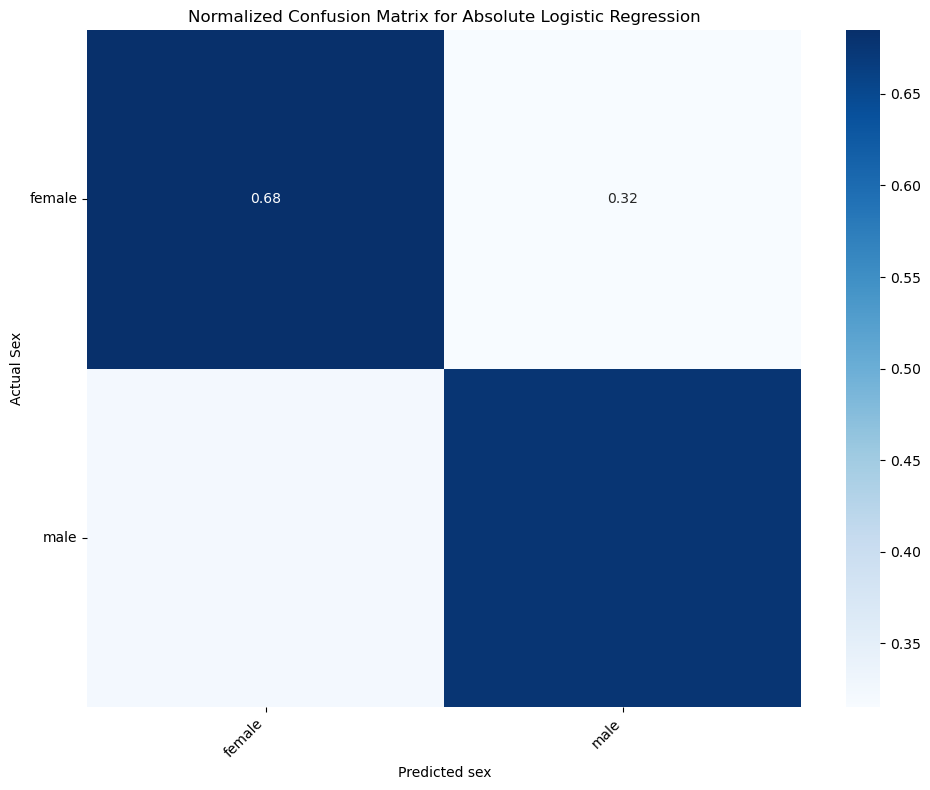

In [3]:
logreg = LogisticRegression(solver='saga', class_weight="balanced")
abs_logreg = logreg.fit(abs_X_train_log, abs_Y_train)

# Validation set
val_preds = abs_logreg.predict(abs_X_val_log)
print("Validation accuracy:", accuracy_score(abs_Y_val, val_preds))

# Test set
abs_test_preds = abs_logreg.predict(abs_X_test_log)
abs_lr_accuracy = accuracy_score(abs_Y_test, abs_test_preds)
print("Test accuracy:", abs_lr_accuracy)
y_prob = abs_logreg.predict_proba(abs_X_test_log)[:, 1]
print("AUC:", roc_auc_score(abs_Y_test, y_prob))

cm = confusion_matrix(abs_Y_test, abs_test_preds)
labels = abs_logreg.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Absolute Logistic Regression")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("sex_abs_lr_cm.png", format="png")
plt.show()

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Validation accuracy: 0.7086614173228346
Test accuracy: 0.6708661417322834
AUC: 0.7438543417366946


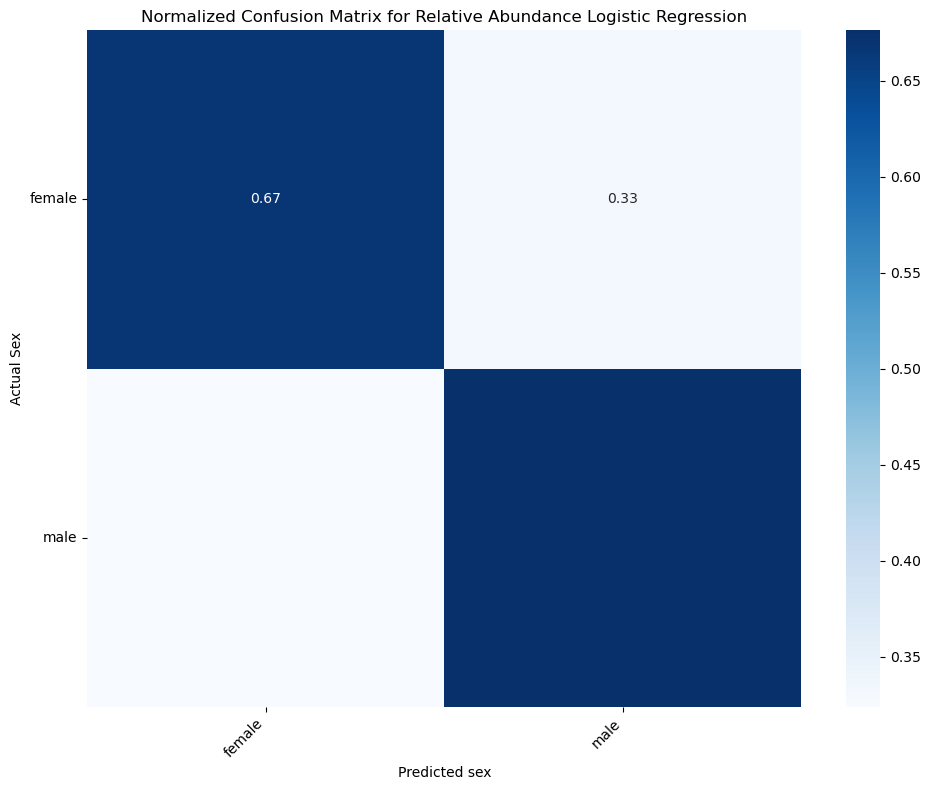

In [4]:
logreg = LogisticRegression(solver='saga', class_weight="balanced")
rel_logreg = logreg.fit(rel_X_train_log, rel_Y_train)

# Validation set
val_preds = rel_logreg.predict(rel_X_val_log)
print("Validation accuracy:", accuracy_score(rel_Y_val, val_preds))

# Test set
rel_test_preds = rel_logreg.predict(rel_X_test_log)
rel_lr_accuracy = accuracy_score(rel_Y_test, rel_test_preds)
print("Test accuracy:", rel_lr_accuracy)
y_prob = abs_logreg.predict_proba(rel_X_test_log)[:, 1]
print("AUC:", roc_auc_score(rel_Y_test, y_prob))

cm = confusion_matrix(rel_Y_test, rel_test_preds)
labels = abs_logreg.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Relative Abundance Logistic Regression")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("sex_rel_lr_cm.png", format="png")
plt.show()

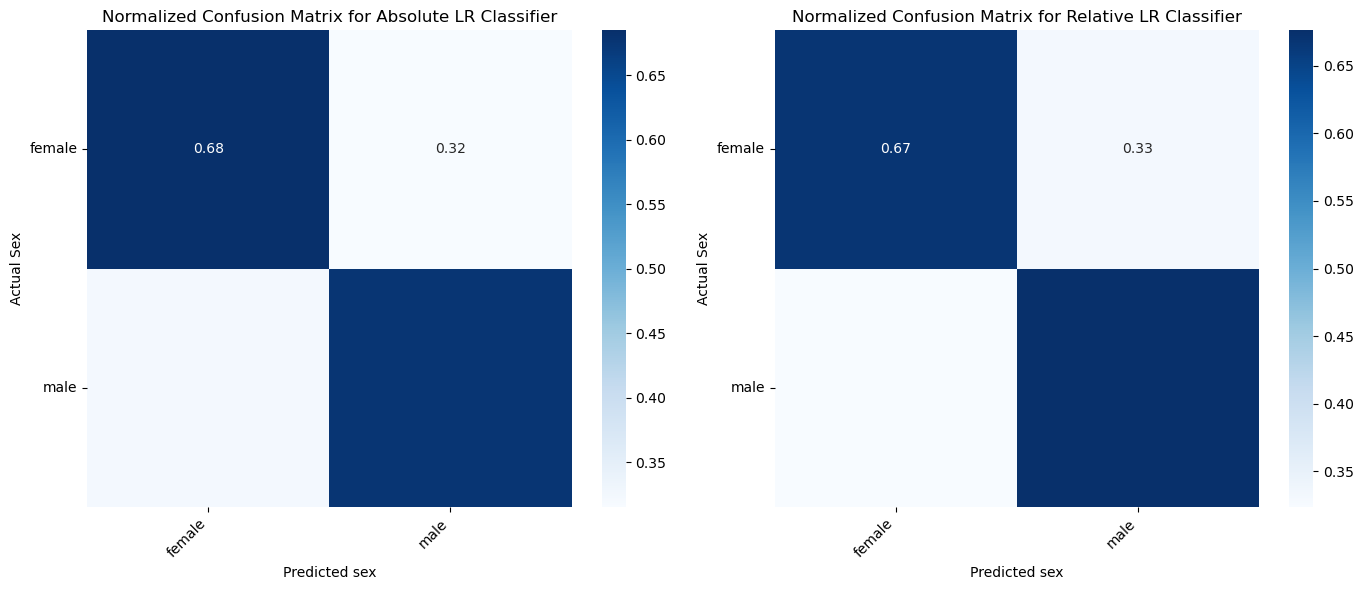

In [9]:
# Comparison side-by-side
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute
abs_test_preds = abs_logreg.predict(abs_X_test_log)
cm = confusion_matrix(abs_Y_test, abs_test_preds)
labels = abs_logreg.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_xlabel("Predicted sex")
axes[0].set_ylabel("Actual Sex")
axes[0].set_xticklabels(labels, rotation=45, ha="right")
axes[0].set_yticklabels(labels, rotation=0)
axes[0].set_title("Normalized Confusion Matrix for Absolute LR Classifier")

# Relative
rel_test_preds = rel_logreg.predict(rel_X_test_log)
cm = confusion_matrix(rel_Y_test, rel_test_preds)
labels = rel_logreg.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_xlabel("Predicted sex")
axes[1].set_ylabel("Actual Sex")
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_yticklabels(labels, rotation=0)
axes[1].set_title("Normalized Confusion Matrix for Relative LR Classifier")
plt.savefig("sex_lr_cm_comparison.png", format="png")
plt.tight_layout()
plt.show()

In [10]:
print(classification_report(abs_Y_test, abs_test_preds))
print(classification_report(rel_Y_test, rel_test_preds))

              precision    recall  f1-score   support

      female       0.81      0.68      0.74       425
        male       0.51      0.68      0.58       210

    accuracy                           0.68       635
   macro avg       0.66      0.68      0.66       635
weighted avg       0.71      0.68      0.69       635

              precision    recall  f1-score   support

      female       0.81      0.67      0.73       425
        male       0.50      0.68      0.58       210

    accuracy                           0.67       635
   macro avg       0.65      0.67      0.65       635
weighted avg       0.71      0.67      0.68       635



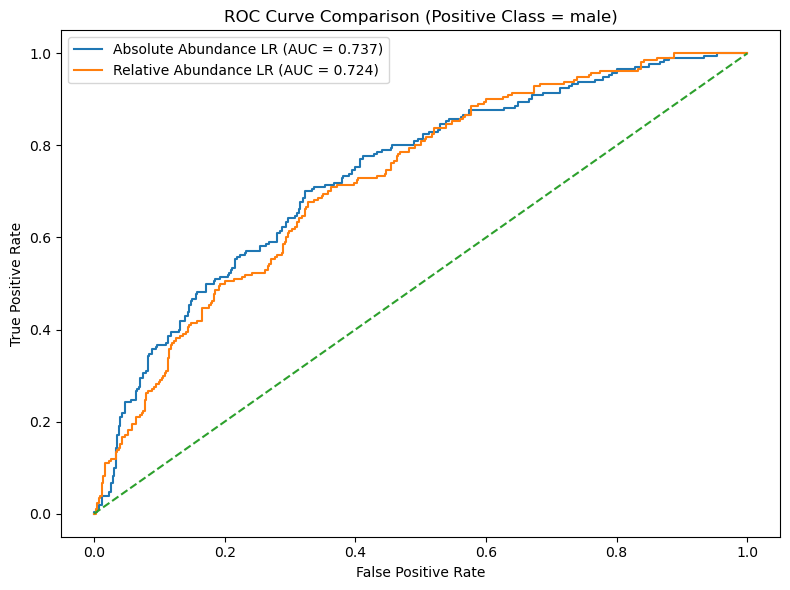

In [11]:
# Plotting the Macro-AUC
# Choosing male as the positive class
pos_class = "male"
abs_pos_index = list(abs_logreg.classes_).index(pos_class)
rel_pos_index = list(rel_logreg.classes_).index(pos_class)

abs_probs = abs_logreg.predict_proba(abs_X_test_log)[:, abs_pos_index]
rel_probs = rel_logreg.predict_proba(rel_X_test_log)[:, rel_pos_index]

abs_fpr, abs_tpr, _ = roc_curve(abs_Y_test, abs_probs, pos_label=pos_class)
rel_fpr, rel_tpr, _ = roc_curve(rel_Y_test, rel_probs, pos_label=pos_class)

abs_auc = auc(abs_fpr, abs_tpr)
rel_auc = auc(rel_fpr, rel_tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(abs_fpr, abs_tpr,
         label=f"Absolute Abundance LR (AUC = {abs_auc:.3f})")
plt.plot(rel_fpr, rel_tpr,
         label=f"Relative Abundance LR (AUC = {rel_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve Comparison (Positive Class = {pos_class})")
plt.legend()
plt.tight_layout()
plt.savefig("sex_lr_roc_comparison.png", format="png")
plt.show()

In [12]:
# Bootstrapping to see if results are significant
n_boot = 1000
rng = np.random.default_rng(42)

acc_diffs = []
auc_diffs = []

y_abs_true = abs_Y_test.to_numpy()
y_rel_true = rel_Y_test.to_numpy()

y_abs_pred = abs_logreg.predict(abs_X_test_log)
y_rel_pred = rel_logreg.predict(rel_X_test_log)

abs_y_prob = abs_logreg.predict_proba(abs_X_test_log)[:, 1]
rel_y_prob = rel_logreg.predict_proba(rel_X_test_log)[:, 1]

def stratified_bootstrap_indices(y, rng):
    indices = []
    classes = np.unique(y)

    for c in classes:
        class_idx = np.where(y == c)[0]
        boot_idx = rng.choice(class_idx, size=len(class_idx), replace=True)
        indices.extend(boot_idx)

    return np.array(indices)

# Bootstrap
for _ in range(n_boot):

    indices = stratified_bootstrap_indices(y_abs_true, rng)

    # Accuracy
    acc_abs = accuracy_score(y_abs_true[indices], y_abs_pred[indices])
    acc_rel = accuracy_score(y_rel_true[indices], y_rel_pred[indices])
    acc_diffs.append(acc_abs - acc_rel)

    # Binary AUC
    auc_abs = roc_auc_score(y_abs_true[indices], abs_y_prob[indices])
    auc_rel = roc_auc_score(y_rel_true[indices], rel_y_prob[indices])
    auc_diffs.append(auc_abs - auc_rel)

# Confidence Interval
acc_ci = np.percentile(acc_diffs, [2.5, 97.5])
auc_ci = np.percentile(auc_diffs, [2.5, 97.5])

print("Accuracy difference 95% CI (Abs - Rel):", acc_ci)
print("Macro-AUC difference 95% CI (Abs - Rel):", auc_ci)

# Interpretation
if acc_ci[0] > 0 or acc_ci[1] < 0:
    print("Accuracy difference is statistically significant.")
else:
    print("Accuracy difference is NOT statistically significant.")

if auc_ci[0] > 0 or auc_ci[1] < 0:
    print("AUC difference is statistically significant.")
else:
    print("AUC difference is NOT statistically significant.")

Accuracy difference 95% CI (Abs - Rel): [-0.02204724  0.04413386]
Macro-AUC difference 95% CI (Abs - Rel): [-0.01645126  0.04178179]
Accuracy difference is NOT statistically significant.
AUC difference is NOT statistically significant.


In [13]:
# Feature importance
# Absolute abundance logistic regression
abs_feat_importance = pd.DataFrame({
    "feature": abs_X_train_log.columns,
    "importance": np.abs(abs_logreg.coef_[0]) 
}).sort_values(by="importance", ascending=False)

# Relative abundance logistic regression
rel_feat_importance = pd.DataFrame({
    "feature": rel_X_train_log.columns,
    "importance": np.abs(rel_logreg.coef_[0])  
}).sort_values(by="importance", ascending=False)

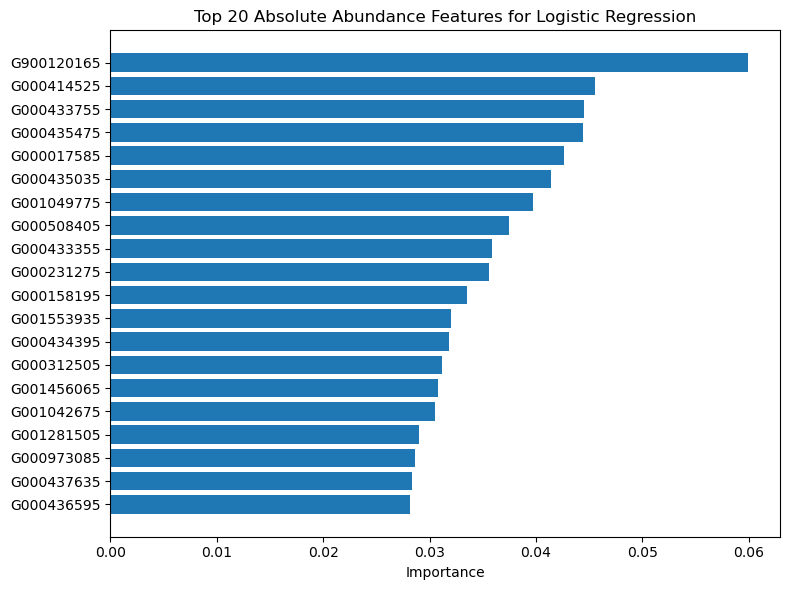

In [14]:
top_n = 20

plt.figure(figsize=(8,6))
plt.barh(
    abs_feat_importance["feature"][:top_n][::-1],
    abs_feat_importance["importance"][:top_n][::-1]
)
plt.title("Top 20 Absolute Abundance Features for Logistic Regression")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("sex_abs_lr_top20_features.png", format="png")
plt.show()

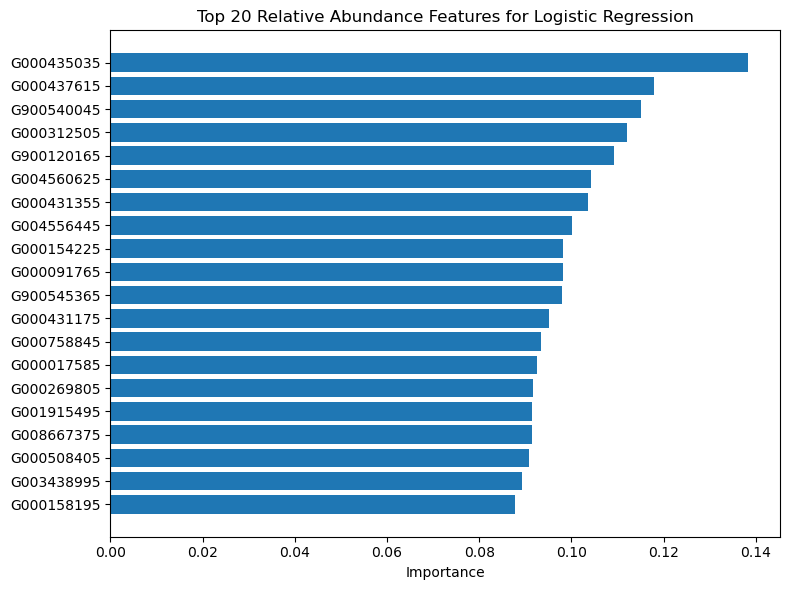

In [18]:
top_n = 20

plt.figure(figsize=(8,6))
plt.barh(
    rel_feat_importance["feature"][:top_n][::-1],
    rel_feat_importance["importance"][:top_n][::-1]
)
plt.title("Top 20 Relative Abundance Features for Logistic Regression")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("sex_rel_lr_top20_features.png", format="png")
plt.show()

In [19]:
# Top 20 feature names
abs_top20 = set(abs_feat_importance["feature"].head(20))
rel_top20 = set(rel_feat_importance["feature"].head(20))

overlap = abs_top20.intersection(rel_top20)
print("Overlap:", overlap)
print("Number overlapping:", len(overlap))
print("Unique to Absolute:", abs_top20 - rel_top20)
print("Unique to Relative:", rel_top20 - abs_top20)

Overlap: {'G000017585', 'G000508405', 'G900120165', 'G000312505', 'G000435035', 'G000158195'}
Number overlapping: 6
Unique to Absolute: {'G001042675', 'G000973085', 'G000434395', 'G001456065', 'G000231275', 'G000437635', 'G000436595', 'G001553935', 'G000414525', 'G000433755', 'G001049775', 'G000435475', 'G001281505', 'G000433355'}
Unique to Relative: {'G008667375', 'G000437615', 'G000431355', 'G004560625', 'G000091765', 'G900545365', 'G000269805', 'G003438995', 'G900540045', 'G001915495', 'G000431175', 'G000758845', 'G000154225', 'G004556445'}


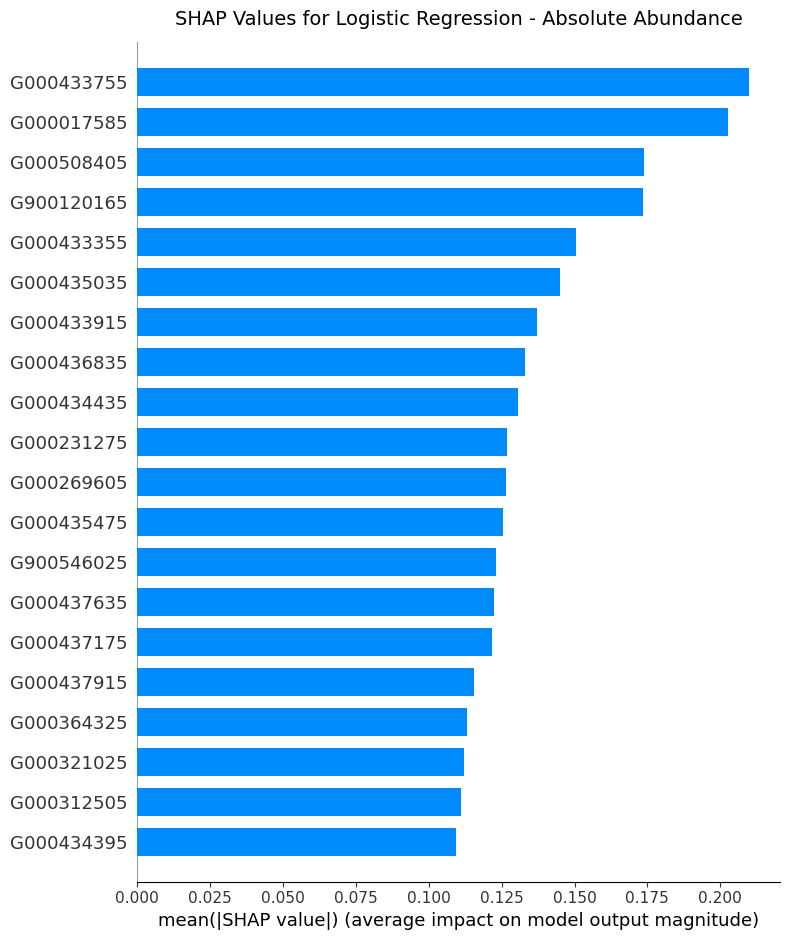

In [20]:
# SHAP Analysis
# Absolute
X = abs_X_test_log.copy()
X = X[abs_logreg.feature_names_in_]

abs_explainer = shap.LinearExplainer(abs_logreg, X, feature_peturbation="independent")
abs_shap = abs_explainer(X)

sv = abs_shap.values
if sv.ndim == 3:
    class_idx = 1
    sv = sv[:, :, class_idx]

plt.figure(figsize=(8, 6))
shap.summary_plot(
    sv, X,
    plot_type="bar",
    max_display=20,
    show=False
)

ax = plt.gca()
ax.set_title("SHAP Values for Logistic Regression - Absolute Abundance", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("sex_abs_lr_shap.png", format="png")
plt.show()

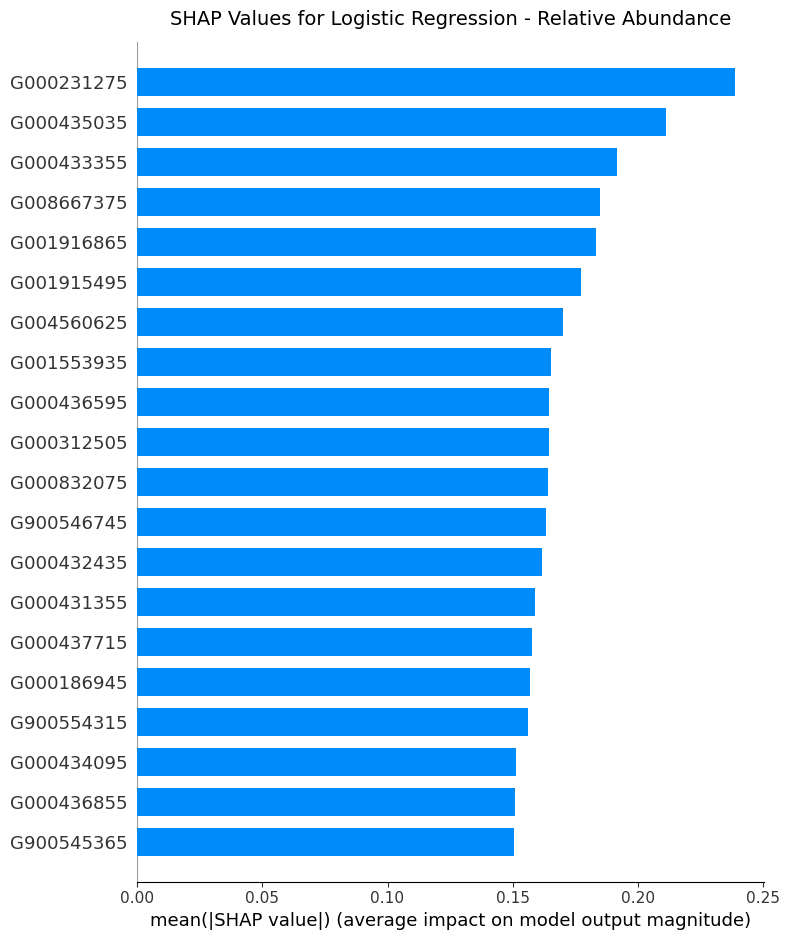

In [21]:
# SHAP Analysis
# Relative
X = rel_X_test_log.copy()
X = X[rel_logreg.feature_names_in_]

rel_explainer = shap.LinearExplainer(rel_logreg, X, feature_peturbation="independent")
abs_shap = abs_explainer(X)

sv = abs_shap.values
if sv.ndim == 3:
    class_idx = 1
    sv = sv[:, :, class_idx]

plt.figure(figsize=(8, 6))
shap.summary_plot(
    sv, X,
    plot_type="bar",
    max_display=20,
    show=False
)

ax = plt.gca()
ax.set_title("SHAP Values for Logistic Regression - Relative Abundance", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("sex_rel_lr_shap.png", format="png")
plt.show()

# SVM

In [22]:
# Absolute
# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True))
])

# Param grid
param_grid = {
    "svc__C": [0.01, 0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1],
    "svc__kernel": ["rbf"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

abs_grid = grid.fit(abs_X_train_log, abs_Y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Best params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV AUC: 0.7144422529037915


Validation AUC: <function auc at 0x2ac8d58b1870>
Validation Balanced Accuracy: 0.6954116498535633
Test AUC: 0.7370588235294118
Test Balanced Accuracy: 0.6783193277310924


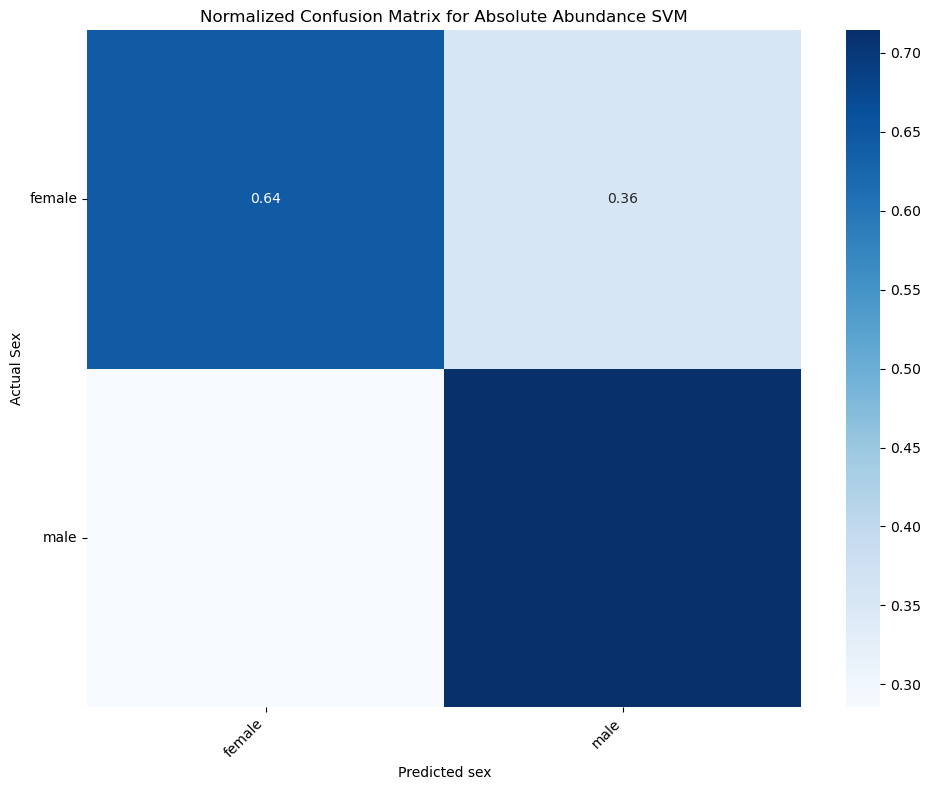

In [24]:
# Evaluate on validation set
abs_best_model = abs_grid.best_estimator_

y_probs = abs_best_model.predict_proba(abs_X_val_log)[:, 1]
y_preds = abs_best_model.predict(abs_X_val_log)

abs_val_auc = roc_auc_score(abs_Y_val, y_probs)
bal_acc = balanced_accuracy_score(abs_Y_val, y_preds)

print("Validation AUC:", auc)
print("Validation Balanced Accuracy:", bal_acc)

# Test set
test_probs = abs_best_model.predict_proba(abs_X_test_log)[:, 1]
abs_test_pred = abs_best_model.predict(abs_X_test_log)
abs_test_auc = roc_auc_score(abs_Y_test, test_probs)
abs_bal_acc = balanced_accuracy_score(abs_Y_test, abs_test_pred)
print("Test AUC:", abs_test_auc)
print("Test Balanced Accuracy:", abs_bal_acc)

cm = confusion_matrix(abs_Y_test, abs_test_pred)
labels = abs_best_model.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Absolute Abundance SVM")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("sex_abs_svm_cm.png", format="png")
plt.show()

Best params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV AUC: 0.733903133903134
Validation AUC: 0.7953024034215053
Validation Balanced Accuracy: 0.7048893589326392
Test AUC: 0.7612436974789916
Test Balanced Accuracy: 0.6876750700280112


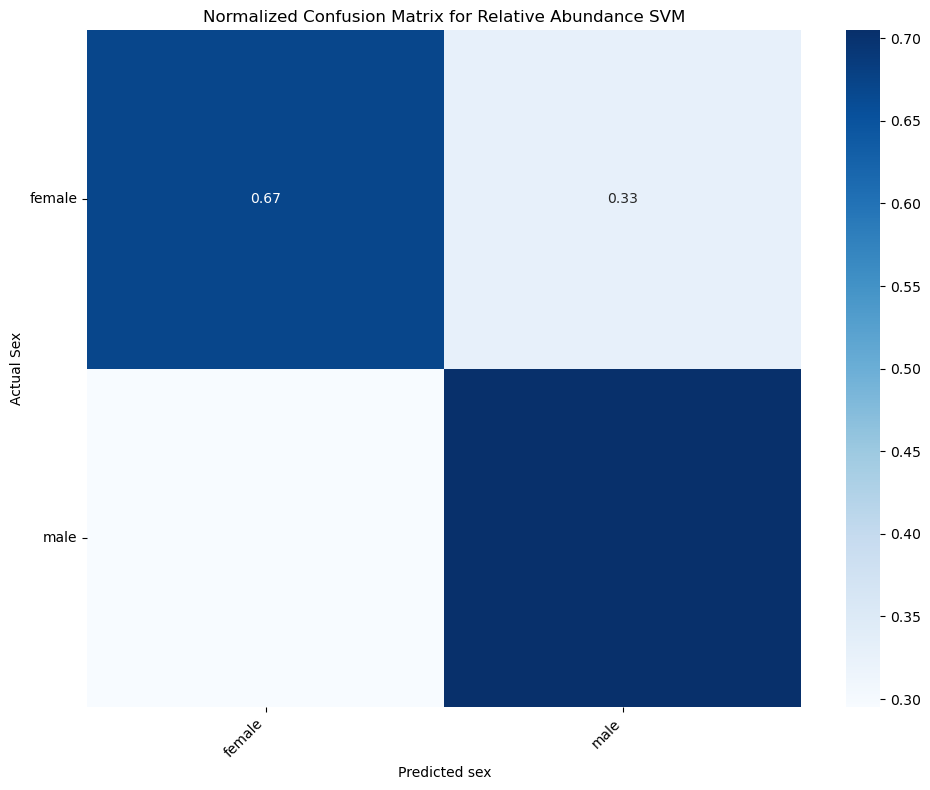

In [26]:
rel_grid = grid.fit(rel_X_train_log, rel_Y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

# Evaluate on validation set
rel_best_model = rel_grid.best_estimator_

y_probs = rel_best_model.predict_proba(rel_X_val_log)[:, 1]
y_pred = rel_best_model.predict(rel_X_val_log)

rel_val_auc = roc_auc_score(rel_Y_val, y_probs)
bal_acc = balanced_accuracy_score(rel_Y_val, y_pred)

print("Validation AUC:", rel_val_auc)
print("Validation Balanced Accuracy:", bal_acc)

# Test set
test_probs = rel_best_model.predict_proba(rel_X_test_log)[:, 1]
rel_test_pred = rel_best_model.predict(rel_X_test_log)
rel_test_auc = roc_auc_score(rel_Y_test, test_probs)
rel_bal_acc = balanced_accuracy_score(rel_Y_test, rel_test_pred)
print("Test AUC:", rel_test_auc)
print("Test Balanced Accuracy:", rel_bal_acc)

cm = confusion_matrix(rel_Y_test, rel_test_pred)
labels = abs_best_model.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted sex")
plt.ylabel("Actual Sex")
plt.title("Normalized Confusion Matrix for Relative Abundance SVM")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("sex_rel_svm_cm.png", format="png")
plt.show()

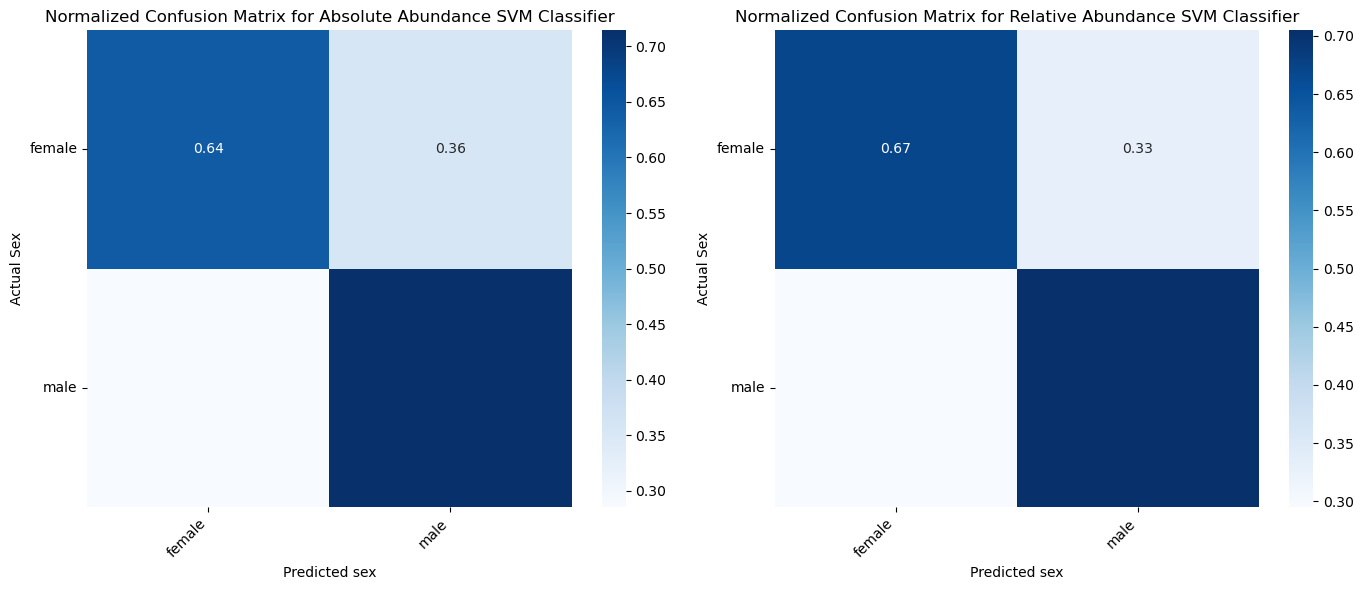

In [28]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute
cm = confusion_matrix(abs_Y_test, abs_test_pred)
labels = abs_best_model.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_xlabel("Predicted sex")
axes[0].set_ylabel("Actual Sex")
axes[0].set_xticklabels(labels, rotation=45, ha="right")
axes[0].set_yticklabels(labels, rotation=0)
axes[0].set_title("Normalized Confusion Matrix for Absolute Abundance SVM Classifier")

# Relative
cm = confusion_matrix(rel_Y_test, rel_test_pred)
labels = rel_best_model.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_xlabel("Predicted sex")
axes[1].set_ylabel("Actual Sex")
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_yticklabels(labels, rotation=0)
axes[1].set_title("Normalized Confusion Matrix for Relative Abundance SVM Classifier")
plt.savefig("sex_svm_cm_comparison.png", format="png")
plt.tight_layout()
plt.show()

In [30]:
print(classification_report(abs_Y_test, abs_test_pred))
print(classification_report(rel_Y_test, rel_test_pred))

              precision    recall  f1-score   support

      female       0.82      0.64      0.72       425
        male       0.50      0.71      0.59       210

    accuracy                           0.67       635
   macro avg       0.66      0.68      0.65       635
weighted avg       0.71      0.67      0.68       635

              precision    recall  f1-score   support

      female       0.82      0.67      0.74       425
        male       0.51      0.70      0.59       210

    accuracy                           0.68       635
   macro avg       0.67      0.69      0.67       635
weighted avg       0.72      0.68      0.69       635



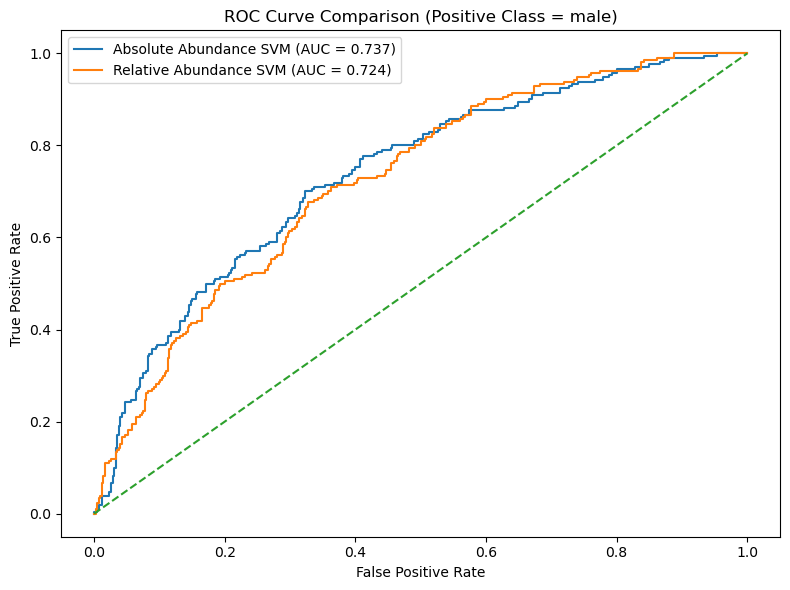

In [32]:
# Plotting the Macro-AUC
# Choosing male as the positive class
pos_class = "male"
abs_pos_index = list(abs_best_model.classes_).index(pos_class)
rel_pos_index = list(rel_best_model.classes_).index(pos_class)

abs_probs = abs_logreg.predict_proba(abs_X_test_log)[:, abs_pos_index]
rel_probs = rel_logreg.predict_proba(rel_X_test_log)[:, rel_pos_index]

abs_fpr, abs_tpr, _ = roc_curve(abs_Y_test, abs_probs, pos_label=pos_class)
rel_fpr, rel_tpr, _ = roc_curve(rel_Y_test, rel_probs, pos_label=pos_class)

abs_auc = auc(abs_fpr, abs_tpr)
rel_auc = auc(rel_fpr, rel_tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(abs_fpr, abs_tpr,
         label=f"Absolute Abundance SVM (AUC = {abs_auc:.3f})")
plt.plot(rel_fpr, rel_tpr,
         label=f"Relative Abundance SVM (AUC = {rel_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve Comparison (Positive Class = {pos_class})")
plt.legend()
plt.tight_layout()
plt.savefig("sex_svm_roc_comparison.png", format="png")
plt.show()

In [33]:
# Bootstrapping to see if results are significant
n_boot = 1000
rng = np.random.default_rng(42)

acc_diffs = []
auc_diffs = []

y_abs_true = abs_Y_test.to_numpy()
y_rel_true = rel_Y_test.to_numpy()

y_abs_pred = abs_best_model.predict(abs_X_test_log)
y_rel_pred = rel_best_model.predict(rel_X_test_log)

abs_y_prob = abs_best_model.predict_proba(abs_X_test_log)[:, 1]
rel_y_prob = rel_best_model.predict_proba(rel_X_test_log)[:, 1]

def stratified_bootstrap_indices(y, rng):
    indices = []
    classes = np.unique(y)

    for c in classes:
        class_idx = np.where(y == c)[0]
        boot_idx = rng.choice(class_idx, size=len(class_idx), replace=True)
        indices.extend(boot_idx)

    return np.array(indices)

# Bootstrap
for _ in range(n_boot):

    indices = stratified_bootstrap_indices(y_abs_true, rng)

    # Accuracy
    acc_abs = accuracy_score(y_abs_true[indices], y_abs_pred[indices])
    acc_rel = accuracy_score(y_rel_true[indices], y_rel_pred[indices])
    acc_diffs.append(acc_abs - acc_rel)

    # Binary AUC
    auc_abs = roc_auc_score(y_abs_true[indices], abs_y_prob[indices])
    auc_rel = roc_auc_score(y_rel_true[indices], rel_y_prob[indices])
    auc_diffs.append(auc_abs - auc_rel)

# Confidence Interval
acc_ci = np.percentile(acc_diffs, [2.5, 97.5])
auc_ci = np.percentile(auc_diffs, [2.5, 97.5])

print("Accuracy difference 95% CI (Abs - Rel):", acc_ci)
print("Macro-AUC difference 95% CI (Abs - Rel):", auc_ci)

# Interpretation
if acc_ci[0] > 0 or acc_ci[1] < 0:
    print("Accuracy difference is statistically significant.")
else:
    print("Accuracy difference is NOT statistically significant.")

if auc_ci[0] > 0 or auc_ci[1] < 0:
    print("AUC difference is statistically significant.")
else:
    print("AUC difference is NOT statistically significant.")

Accuracy difference 95% CI (Abs - Rel): [-0.0519685   0.01732283]
Macro-AUC difference 95% CI (Abs - Rel): [-0.05267703  0.00361961]
Accuracy difference is NOT statistically significant.
AUC difference is NOT statistically significant.


In [ ]:
# # Note: Unable to do feature importance due to the RBF Kernel
# background_sample = 50   
# test_sample = 100        
# random_state = 42

# # Absolute
# abs_svm = abs_grid.best_estimator_

# def abs_predict_proba(X):
#     return abs_svm.predict_proba(X)

# abs_X_bg = abs_X_train_log.sample(background_sample, random_state=random_state)
# abs_X_test_sample = abs_X_test_log.sample(test_sample, random_state=random_state)

# abs_explainer = shap.KernelExplainer(abs_predict_proba, abs_X_bg)
# abs_shap_values = abs_explainer.shap_values(abs_X_test_sample)
# abs_shap_class1 = abs_shap_values[1]

# abs_feat_importance = pd.DataFrame({
#     "feature": abs_X_test_sample.columns,
#     "importance": abs_shap_class1.abs().mean(axis=0)
# }).sort_values(by="importance", ascending=False)

# # Plot summary
# plt.figure(figsize=(8,6))
# shap.summary_plot(
#     abs_shap_class1, abs_X_test_sample,
#     plot_type="bar",
#     max_display=20,
#     show=False
# )
# plt.title("SHAP Values - Absolute Abundance (RBF SVM)", fontsize=14, pad=12)
# plt.tight_layout()
# plt.savefig("shap_abs_svm.png", format="png")
# plt.show()

# print("Top Absolute Abundance Features:")
# print(abs_feat_importance.head(10))

# # Relative abundance
# rel_svm = rel_grid.best_estimator_

# # Wrapper function for KernelExplainer
# def rel_predict_proba(X):
#     return rel_svm.predict_proba(X)

# # Sample background and test sets
# rel_X_bg = rel_X_train_log.sample(background_sample, random_state=random_state)
# rel_X_test_sample = rel_X_test_log.sample(test_sample, random_state=random_state)

# # KernelExplainer
# rel_explainer = shap.KernelExplainer(rel_predict_proba, rel_X_bg)
# rel_shap_values = rel_explainer.shap_values(rel_X_test_sample)

# # Take class 1 (male)
# rel_shap_class1 = rel_shap_values[1]

# # Global feature importance
# rel_feat_importance = pd.DataFrame({
#     "feature": rel_X_test_sample.columns,
#     "importance": rel_shap_class1.abs().mean(axis=0)
# }).sort_values(by="importance", ascending=False)

# # Plot summary
# plt.figure(figsize=(8,6))
# shap.summary_plot(
#     rel_shap_class1, rel_X_test_sample,
#     plot_type="bar",
#     max_display=20,
#     show=False
# )
# plt.title("SHAP Values - Relative Abundance (RBF SVM)", fontsize=14, pad=12)
# plt.tight_layout()
# plt.savefig("shap_rel_svm.png", format="png")
# plt.show()

# print("Top Relative Abundance Features:")
# print(rel_feat_importance.head(10))

# Testing to see if better than Random

In [34]:
# Testing on balanced validation/test
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Balancing the training set
# Absolute quant
target_n = 585

abs_balanced_train = (
    abs_train
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Balancing test
# Absolute quant
target_n = 210

abs_balanced_test = (
    abs_test
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_test = (
    rel_test
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Balancing validation
# Absolute quant
target_n = 196

abs_balanced_val = (
    abs_val
    .groupby('sex', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_val = (
    rel_val
    .groupby("sex", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# # Splitting into features and targets
# Absolute
abs_X_train = (
    abs_balanced_train[abs_balanced_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
)
abs_Y_train = abs_balanced_train['sex']

abs_X_bal_test = (
    abs_balanced_test[abs_balanced_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
)
abs_Y_bal_test = abs_balanced_test['sex']

abs_X_bal_val = (
    abs_balanced_val[abs_balanced_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
)
abs_Y_bal_val = abs_balanced_val['sex']

# Absolute
rel_X_train = (
    rel_balanced_train[rel_balanced_train.columns[:1148]]
        .drop(columns=['original_SampleID'])
)
rel_Y_train = rel_balanced_train['sex']

rel_X_bal_test = (
    rel_balanced_test[rel_balanced_test.columns[:1148]]
        .drop(columns=['original_SampleID'])
)
rel_Y_bal_test = rel_balanced_test['sex']

rel_X_bal_val = (
    rel_balanced_val[rel_balanced_val.columns[:1148]]
        .drop(columns=['original_SampleID'])
)
rel_Y_bal_val = rel_balanced_val['sex']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_bal_log = abs_X_train.copy()
abs_X_train_bal_log = np.log1p(abs_X_train_log)

abs_X_test_bal_log = abs_X_bal_test.copy()
abs_X_test_bal_log = np.log1p(abs_X_test_bal_log)

abs_X_val_bal_log = abs_X_bal_val.copy()
abs_X_val_bal_log = np.log1p(abs_X_val_bal_log)

# Relative abundance data
rel_X_train_bal_log = rel_X_train.copy()
rel_X_train_bal_log = np.log1p(rel_X_train_log)

rel_X_test_bal_log = rel_X_bal_test.copy()
rel_X_test_bal_log = np.log1p(rel_X_test_log)

rel_X_val_bal_log = rel_X_bal_val.copy()
rel_X_val_bal_log = np.log1p(rel_X_val_bal_log)

/tmp/ipykernel_9253/2855837657.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_9253/2855837657.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_9253/2855837657.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the groupi

In [35]:
abs_val_preds = abs_logreg.predict(abs_X_val_bal_log)
print("val accuracy:", accuracy_score(abs_Y_bal_val, abs_val_preds))

abs_bal_val_preds = abs_best_model.predict(abs_X_val_bal_log)
print("val accuracy:", accuracy_score(abs_Y_bal_val, abs_bal_val_preds))

val accuracy: 0.6581632653061225
val accuracy: 0.673469387755102


In [36]:
rel_val_preds = rel_logreg.predict(rel_X_val_bal_log)
print("val accuracy:", accuracy_score(rel_Y_bal_val, rel_val_preds))

rel_bal_val_preds = rel_best_model.predict(rel_X_val_bal_log)
print("val accuracy:", accuracy_score(rel_Y_bal_val, rel_bal_val_preds))

val accuracy: 0.6913265306122449
val accuracy: 0.7040816326530612
